In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src" / "context_scaling" / "scripts"))
sys.path.insert(0, str(REPO_ROOT / "src"))

from setup_eval import get_wandb_table
from core.utils import solve_config_lr

## Helpers

In [2]:
def flatten_config_columns(df: pd.DataFrame, sep: str = "/") -> pd.DataFrame:
    """Expand dict-valued `config/*` columns into flat columns.

    wandb stores the nested OmegaConf config, so `run.config.items()` yields
    top-level keys like `common`, `trainer` with dict values. This walks those
    dicts and produces columns like `config/trainer/learning_rate`.
    """
    df = df.copy()

    def walk(prefix, value, out):
        if isinstance(value, dict):
            for k, v in value.items():
                walk(f"{prefix}{sep}{k}", v, out)
        else:
            out[prefix] = value

    config_cols = [c for c in df.columns if c.startswith("config/")]
    new_rows = []
    for _, row in df.iterrows():
        flat = {}
        for c in config_cols:
            walk(c, row[c], flat)
        new_rows.append(flat)

    flat_df = pd.DataFrame(new_rows, index=df.index)
    df = df.drop(columns=config_cols)
    return pd.concat([df, flat_df], axis=1)

In [3]:
def get_final_loss_values(runs_table, lr_col, loss_col, main_variables):
    rows = []
    for _, run_row in runs_table.iterrows():
        row = {
            "run_id": run_row["sys/id"],
            "lr": run_row[lr_col],
            "final_loss": run_row[loss_col],
        }
        for i, mv in enumerate(main_variables):
            row[f"grid_val_{i}"] = run_row[mv]
        rows.append(row)
    return pd.DataFrame(rows)


def plot_loss_vs_lr(
    runs_table,
    main_variables,
    lr_col="config/trainer/learning_rate",
    loss_col="summary/steps/eval/loss",
    n_steps_col="config/trainer/n_steps",
    step_col="summary/step",
    ylim=None,
    title=None,
    ax=None,
    ax_labels_font=12,
    tick_font=12,
    title_font=12,
    var_labels=None,
):
    """Plot final eval loss vs learning rate, one line per `main_variables` combo.

    Expects a wandb-style dataframe (columns prefixed `config/` and `summary/`).
    Finished runs (step+1 >= n_steps) are drawn with circles + solid lines;
    running runs are drawn with squares + dashed lines.
    """
    color_dict = {
        0: "#1f78b4", 1: "#33a02c", 2: "#e31a1c", 3: "#ff7f00",
        4: "#6a3d9a", 5: "#a65628", 6: "#000000",
    }

    required = ["sys/id", lr_col, loss_col, n_steps_col, step_col, *main_variables]
    missing = [c for c in required if c not in runs_table.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    final_loss_df = get_final_loss_values(
        runs_table, lr_col=lr_col, loss_col=loss_col, main_variables=main_variables
    )
    final_loss_df = final_loss_df[final_loss_df["final_loss"].notnull()]

    completion_map = {
        r["sys/id"]: "complete" if (r[step_col] + 1 >= r[n_steps_col]) else "running"
        for _, r in runs_table.iterrows()
    }
    final_loss_df["status"] = final_loss_df["run_id"].map(completion_map)

    grid_cols = [f"grid_val_{i}" for i in range(len(main_variables))]
    grid_val_sets = (
        final_loss_df[grid_cols]
        .drop_duplicates()
        .sort_values(grid_cols)
        .itertuples(index=False, name=None)
    )

    var_labels = var_labels or {}

    for color_num, grid_vals in enumerate(grid_val_sets):
        mask = (final_loss_df[grid_cols] == grid_vals).all(axis=1)
        subset = final_loss_df[mask]
        color = color_dict.get(color_num)

        label = ", ".join(
            f"{var_labels.get(name, name)}: {value}"
            for name, value in zip(main_variables, grid_vals)
        )

        target = ax if ax is not None else plt

        finished = subset[subset["status"] == "complete"]
        if not finished.empty:
            means = finished.sort_values("lr").groupby("lr")["final_loss"].mean()
            target.plot(means.index.to_numpy(), means.values, marker="o",
                        color=color, label=label, linestyle="-")

        running = subset[subset["status"] != "complete"]
        if not running.empty:
            means = running.sort_values("lr").groupby("lr")["final_loss"].mean()
            target.plot(means.index.to_numpy(), means.values, marker="s",
                        color=color, label=label, linestyle="--", markersize=6)

    if ax is None:
        plt.legend()
        plt.tick_params(axis="both", labelsize=tick_font)
        plt.xlabel("Learning Rate", fontsize=ax_labels_font)
        plt.ylabel("Final Eval Loss", fontsize=ax_labels_font)
        plt.title(title or "Final Loss vs Learning Rate", fontsize=title_font)
        plt.grid(True)
        plt.xscale("log", base=2)
        if ylim is not None:
            plt.ylim(ylim)
        plt.show()
    else:
        ax.legend()
        ax.set_xlabel("Learning Rate", fontsize=ax_labels_font)
        ax.set_ylabel("Final Eval Loss", fontsize=ax_labels_font)
        ax.tick_params(axis="both", labelsize=tick_font)
        ax.set_xscale("log", base=2)
        ax.set_title(title or "Final Loss vs Learning Rate", fontsize=title_font)
        ax.grid(True)
        if ylim is not None:
            ax.set_ylim(ylim)

## Fetch runs

In [4]:
negative_tags = ["remove"]
project = "ideas_cv/llm-random-test"

def resolve_lr(df):
    # config/trainer/learning_rate is the raw config value; solve_config_lr
    # maps x>=1 to 2**-x so the axis reflects the effective LR used in training.
    df = df.copy()
    df["config/trainer/learning_rate"] = df["config/trainer/learning_rate"].apply(
        lambda x: solve_config_lr(x)[0] if pd.notnull(x) else x
    )
    return df

df_simpleP_raw = get_wandb_table(["nano", "simpleP4"], project=project, negative_tags=negative_tags)
df_simpleP = resolve_lr(flatten_config_columns(df_simpleP_raw))
print("simpleP:", df_simpleP.shape)

df_vanilla_raw = get_wandb_table(["nano", "vanilla2"], project=project, negative_tags=negative_tags)
df_vanilla = resolve_lr(flatten_config_columns(df_vanilla_raw))
print("vanilla:", df_vanilla.shape)

wandb: Currently logged in as: j321m (j321m-uniwersytet-warszawski) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


tags: ['nano', 'simpleP4']
df shape: (38, 514)
simpleP: (38, 712)
tags: ['nano', 'vanilla2']
df shape: (30, 513)
vanilla: (30, 710)


In [5]:
# Inspect available columns to pick the right lr / loss / grouping columns.
for c in sorted(df_simpleP.columns):
    print(c)

config/_run_
config/checkpoint_config/slurm_array_task_id
config/cluster_switch/eval_path_c4
config/cluster_switch/eval_path_fineweb
config/cluster_switch/train_path_c4
config/cluster_switch/train_path_fineweb
config/common/_target_
config/common/batch_size
config/common/data_seed
config/common/datt
config/common/dff
config/common/dmodel
config/common/head_norm
config/common/init_scale
config/common/init_type
config/common/kv_heads
config/common/model_seed
config/common/model_type
config/common/n_blocks
config/common/q_heads
config/common/sequence_length
config/common/tokenizer
config/common/vocab_size
config/evaluator
config/infrastructure/cemetery_experiments_dir
config/infrastructure/generated_configs_path
config/infrastructure/git/remote_name
config/infrastructure/git/remote_url
config/infrastructure/max_concurrent_jobs
config/infrastructure/metric_logger/heavy_metrics_calculation_interval
config/infrastructure/metric_logger/name
config/infrastructure/metric_logger/new_wandb_job
co

## Plot

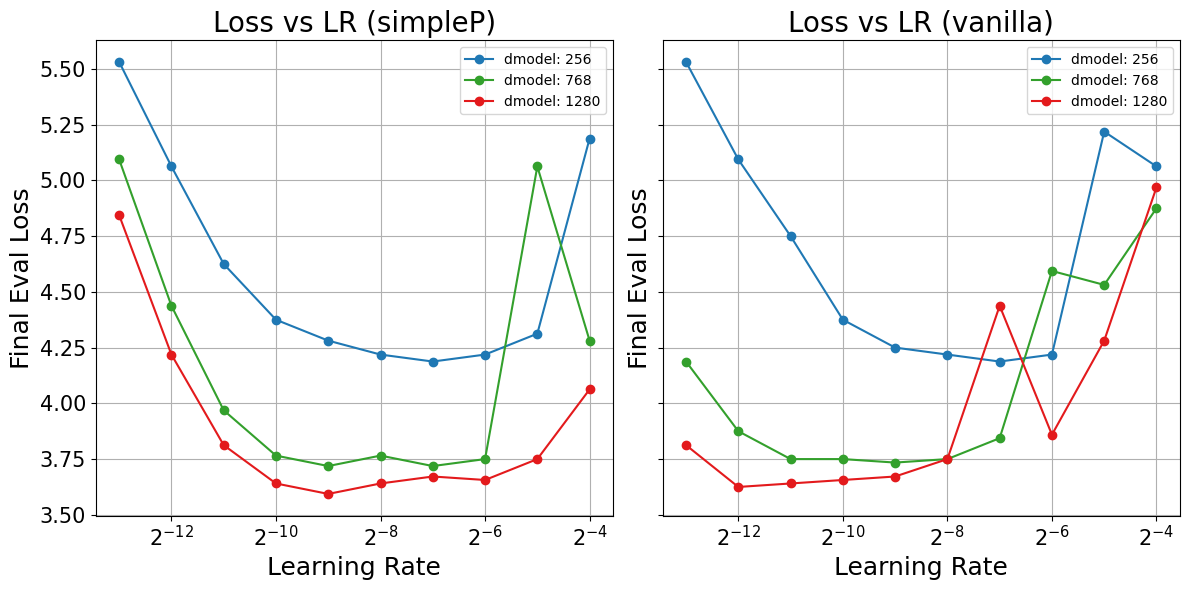

In [6]:
var_labels = {
    "config/common/dmodel": "dmodel",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
plot_loss_vs_lr(
    df_simpleP,
    main_variables=["config/common/dmodel"],
    title="Loss vs LR (simpleP)",
    ax=axes[0],
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    var_labels=var_labels,
)
plot_loss_vs_lr(
    df_vanilla,
    main_variables=["config/common/dmodel"],
    title="Loss vs LR (vanilla)",
    ax=axes[1],
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    var_labels=var_labels,
)
plt.tight_layout()